Assignment:3
1. you have to create one supervisor node.
2. create one router function
3. create three more node
3.1 llm call (llm node)
3.2 RAG (rag node)
3.3 web crawler(fetch the info in realtime from internet)
4. created one more node after this for validation for generated output --> explore the validation part how to do that
5. if validation going to be failed in that case again go to supervioser node and then supervisor node will again decide what needs to be call next
6. once the validation will pass then only generate the final output

submission deadline till 9pm friday

submission instruction:
create your github repo and keep all the assisgnments over there(in that github repo)
i will share one googleform in group after completing your assignment you can share the github link through that google form. 

# Configure the Model


In [87]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [88]:

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [89]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-4o-mini")

In [90]:
output = model.invoke("who is founder of ethireum/eth is eth limited if yes supply ???") 

In [91]:
print(output.content)

Ethereum, which is often referred to by its token name ETH, was co-founded by Vitalik Buterin, along with several other contributors including Gavin Wood, Joseph Lubin, and Anthony Di Iorio. The project was proposed in late 2013 and development began in early 2014, with the network officially launching on July 30, 2015.

Ethereum is not owned by a single entity or company called "Eth Limited." It operates as a decentralized platform, and its development is guided by the community, along with the Ethereum Foundation, a non-profit organization that supports the development of Ethereum.

As for the supply of Ethereum (ETH), it does not have a fixed maximum supply like Bitcoin. Instead, the issuance of ETH is determined by network parameters, which can change over time based on community consensus and protocol updates. Ethereum transitioned to a proof-of-stake consensus mechanism with the Ethereum 2.0 upgrade, which has altered the issuance rate. For the most accurate and up-to-date inform

# Configuring the Embedding model

In [92]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
len(embeddings.embed_query("HEY ETH"))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 699.94it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


384

## lets take a data embeddd it and store in VDB

In [93]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [94]:
loader=DirectoryLoader("../data2",glob="./*.txt",loader_cls=TextLoader)  ## glob is used for whatever files with txt extension will load the file 
##  single dot for current directory  double for parent directory 

In [95]:
docs=loader.load() 

In [96]:
docs

[Document(metadata={'source': '..\\data2\\usa.txt'}, page_content="🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ra

In [97]:
docs[0].page_content  

"🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ranks 2nd). The U.S. GDP per capita is also among the highest, hover

In [98]:
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50 
)   

In [99]:
new_docs=text_splitter.split_documents(documents=docs) 

In [100]:
new_docs

[Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='innovation, global trade,

In [101]:
db=Chroma.from_documents(new_docs,embeddings)

In [102]:
retriever=db.as_retriever(search_kwargs={"k":3})        

In [103]:
retriever.invoke("industrial growth of USA")

[Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='Looking forward, the U.S. economy is expected to grow at a moderate pace, powered by innovation in AI, green energy, robotics, biotech, and quantum computing. The Biden administration’s Inflation')]

In [104]:
retriever.invoke("industrial growth of worlds powerful economy") 

[Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='to dominate the global economy well into the future.'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='to dominate the global economy well into the future.'),
 Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='The U.S. economy remains the engine of global growth, backed by unmatched innovation, financial dominance, and a strong institutional framework. Its $28 trillion GDP and influence over global')]

#### creation of pydantic class

In [105]:
import operator
from typing import List
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,END

In [106]:
class TopicSelectionParser(BaseModel):
    Topic:str=Field(description="selected topic")
    Reasoning:str=Field(description="Reasoning behind topic selection")               
    

In [107]:
from langchain_core.output_parsers import PydanticOutputParser 

In [108]:
parser=PydanticOutputParser(pydantic_object=TopicSelectionParser) 

In [109]:
parser.get_format_instructions() 

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "selected topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

In [110]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add] 
    retry_count : int
    last_called :str
    is_valid : bool
    validation_feedback: str

In [111]:

def function_1(state:AgentState):
    question = state["messages"][-1]

    last_called = state["last_called"]
    validation_feedback = state["validation_feedback"]
    retry_count = state["retry_count"] + 1

    print("Question:-",question)

    template="""
    Your task is to classify the given user query into one of the following categories: [USA,Not Related,Recent or Real-Time Information Required --Use this if the user is asking for current stats, live data, latest news, or information with phrases like "today", "current", "latest", "now"]. 
    Only respond with the category name and nothing else.

    Already tried: {last_called}. Do not route there again.
    Validation feedback from last attempt: {validation_feedback}

    User query: {question}
    {format_instructions}
    """
    prompt= PromptTemplate(
        template=template,
        input_variable=["question","last_called", "validation_feedback"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    ) 

    chain= prompt | model | parser 
    
    response = chain.invoke({"question":question ,"last_called" :last_called , "validation_feedback" :validation_feedback })
    
    print("Parsed response:", response) 

    
    return {"messages": [response.Topic], "retry_count": retry_count}



In [112]:
# state={"messages":["what is a today weather?"]}   

In [113]:
# function_1(state) 

In [114]:
def router(state:AgentState):
    print("------ROUTER------")
    
    last_message=state["messages"][-1]
    print("last_message:", last_message)

    retry_count = state["retry_count"]

    if retry_count >= 9:
        return "force_end" 

    else:
        if "usa" in last_message.lower():
            return "RAG Call"
        elif "Not Related" in last_message.lower():
            return "LLM Call" 
        elif "recent or real-time information required" in last_message.lower():
            return "web crawler"   
        else:
            return "LLM Call" 

    
          
    

In [115]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)  

In [116]:
# RAG Function
def function_2(state:AgentState):
    print("->  ->")
    
    question = state["messages"][0]
    
    prompt=PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you 
        don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer 
        concise.\nQuestion: {question} \nContext: {context} \nAnswer:""",
        
        input_variables=['context', 'question']
    )
    
    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | model
        | StrOutputParser()
    )
    result = rag_chain.invoke(question)
    return  {"messages": [result] , "last_called" : "RAG Call" } 

In [117]:
# LLM Function
def function_3(state:AgentState):
    print("-> LLM Call ->")
    question = state["messages"][0]
    
    # Normal LLM call
    complete_query = "Anwer the follow question with you knowledge of the real world. Following is the user question: " + question
    response = model.invoke(complete_query)
    return {"messages": [response.content] , "last_called" : "LLM Call"}

In [118]:

#  web crawler

from tavily import TavilyClient 
client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))  

def function_4(state: AgentState):
    print("---web crawler Call ---")
    question = state["messages"][0]

    result = client.search(query=question, search_depth="advanced", max_results=3)
    web_result = result["results"][0]["content"] if result["results"] else "No result found"

    return {"messages": [ web_result] , "last_called" : "web crawler"}

In [119]:
class ValidationParser(BaseModel):
    is_valid: bool = Field(description="this describes weather ist valid or not")
    validation_feedback: str = Field(description="its a resoning about validation")

In [120]:
validate_parser = PydanticOutputParser(pydantic_object=ValidationParser)

In [121]:
##  validation 

def function_5(state: AgentState):

    
    print("---Validation---")
    question = state["messages"][0]  
    response = state["messages"][-1] 


    print(question, response)
    validation_prompt = PromptTemplate(
        template="""Think you are evaluator, your task is validate the output of the user question. Example if the response is correct based on the user question then simple say 'True', otherwise say 'False' is the response is not relevant to the question. Think very carefully to validation time. Below the user question and the response of the question.
        the user question is : {question}\n\n and the output response of the question is: {response}.\n\n Most important is must be follow the output format instruction: {format_instruction}""",
        input_variables=["question", "response"],
        partial_variables={
            "format_instruction": validate_parser.get_format_instructions()
        }
    )
    
    validation_chain = validation_prompt | model  | validate_parser
    
    result = validation_chain.invoke(
        {
            "question": question,
            "response": response
        }
    )
    print(result.validation_feedback )
    
    return {
    "is_valid": result.is_valid,
    "validation_feedback": result.validation_feedback
}
    

In [122]:
from langgraph.graph import END

def validation_router(state: AgentState):
    is_valid = state["is_valid"] 
    
    if is_valid :
        return "PASS"
    else:
        return "FAILED"

In [123]:
from langgraph.graph import StateGraph,END 


workflow=StateGraph(AgentState) 

workflow.add_node("Supervisor",function_1) 
workflow.add_node("RAG",function_2)
workflow.add_node("LLM",function_3)
workflow.add_node("web_crawler",function_4)
workflow.add_node("Validation",function_5) 

workflow.set_entry_point("Supervisor") 
workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
        "web crawler": "web_crawler" ,
        "force_end": END
        
    }
)
workflow.add_edge("RAG", "Validation")
workflow.add_edge("LLM", "Validation")
workflow.add_edge("web_crawler", "Validation") 

workflow.add_conditional_edges(
    "Validation",
    validation_router,
    {
        "PASS": END,
        "FAILED": "Supervisor"
    }
)

In [124]:
app=workflow.compile()

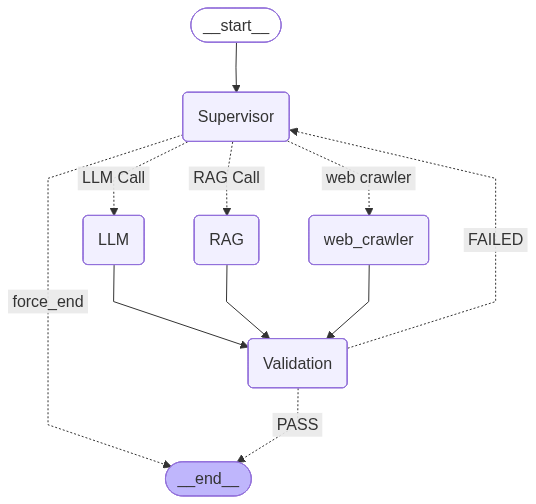

In [125]:
app

In [126]:
# Test 1 - should hit RAG
state = {"messages": ["what is the industrial growth of USA?"], "retry_count": 0, "last_called": None, "is_valid": False, "validation_feedback": ""}
app.invoke(state)

Question:- what is the industrial growth of USA?
Parsed response: Topic='USA' Reasoning='User is asking about the industrial growth of the USA, which is directly related to the country.'
------ROUTER------
last_message: USA
->  ->
---Validation---
what is the industrial growth of USA? The industrial growth of the USA is expected to proceed at a moderate pace, driven by innovations in AI, green energy, robotics, biotech, and quantum computing. The U.S. economy, with a GDP of $28 trillion, continues to be a significant engine of global growth.
The response provides relevant information about the industrial growth of the USA, discussing factors influencing its moderate pace and the overall economic context.


{'messages': ['what is the industrial growth of USA?',
  'USA',
  'The industrial growth of the USA is expected to proceed at a moderate pace, driven by innovations in AI, green energy, robotics, biotech, and quantum computing. The U.S. economy, with a GDP of $28 trillion, continues to be a significant engine of global growth.'],
 'retry_count': 1,
 'last_called': 'RAG Call',
 'is_valid': True,
 'validation_feedback': 'The response provides relevant information about the industrial growth of the USA, discussing factors influencing its moderate pace and the overall economic context.'}

In [127]:
# Test 2 - should hit LLM
state = {"messages": ["what is photosynthesis?"], "retry_count": 0, "last_called": None, "is_valid": False, "validation_feedback": ""}
app.invoke(state)

Question:- what is photosynthesis?
Parsed response: Topic='Not Related' Reasoning='The user query is about photosynthesis, which is a scientific concept and not related to the specified categories.'
------ROUTER------
last_message: Not Related
-> LLM Call ->
---Validation---
what is photosynthesis? Photosynthesis is a biological process through which green plants, algae, and some bacteria convert light energy into chemical energy. During photosynthesis, these organisms use sunlight to convert carbon dioxide (from the air) and water (from the soil) into glucose (a type of sugar) and oxygen. The overall chemical reaction can be summarized by the equation:

\[ \text{6 CO}_2 + \text{6 H}_2\text{O} + \text{light energy} \rightarrow \text{C}_6\text{H}_{12}\text{O}_6 + \text{6 O}_2 \]

In this process, chlorophyll (the green pigment in plants) absorbs sunlight, which drives the reactions that convert the raw materials into glucose and oxygen. The glucose produced can be used by the plant for 

{'messages': ['what is photosynthesis?',
  'Not Related',
  'Photosynthesis is a biological process through which green plants, algae, and some bacteria convert light energy into chemical energy. During photosynthesis, these organisms use sunlight to convert carbon dioxide (from the air) and water (from the soil) into glucose (a type of sugar) and oxygen. The overall chemical reaction can be summarized by the equation:\n\n\\[ \\text{6 CO}_2 + \\text{6 H}_2\\text{O} + \\text{light energy} \\rightarrow \\text{C}_6\\text{H}_{12}\\text{O}_6 + \\text{6 O}_2 \\]\n\nIn this process, chlorophyll (the green pigment in plants) absorbs sunlight, which drives the reactions that convert the raw materials into glucose and oxygen. The glucose produced can be used by the plant for energy and growth, while oxygen is released as a byproduct into the atmosphere. Photosynthesis is essential for life on Earth, as it is the primary source of organic matter for nearly all organisms and plays a crucial role i

In [129]:
# Test 3 - should hit Web Crawler
state = {"messages": ["what is the current bitcoin price today?"], "retry_count": 0, "last_called": None, "is_valid": False, "validation_feedback": ""}
app.invoke(state)

Question:- what is the current bitcoin price today?
Parsed response: Topic='Recent or Real-Time Information Required' Reasoning='The user is asking for the current bitcoin price today, which indicates a request for live data.'
------ROUTER------
last_message: Recent or Real-Time Information Required
---web crawler Call ---
---Validation---
what is the current bitcoin price today? The price of Bitcoin (BTC) is $69736.83 today as of Apr 6, 2026, 10:38 am EDT, with a 24-hour trading volume of $17.11B.
The response correctly provides the current Bitcoin price as requested in the user question.


{'messages': ['what is the current bitcoin price today?',
  'Recent or Real-Time Information Required',
  'The price of Bitcoin (BTC) is $69736.83 today as of Apr 6, 2026, 10:38 am EDT, with a 24-hour trading volume of $17.11B.'],
 'retry_count': 1,
 'last_called': 'web crawler',
 'is_valid': True,
 'validation_feedback': 'The response correctly provides the current Bitcoin price as requested in the user question.'}